In [ ]:
#Installing Libraries
!pip install open_clip_torch
!pip install ftfy regex tqdm

In [2]:
# Importing Libraries
import torch
import torch.nn as nn
import torch.optim as optim
import open_clip
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data import Subset
from tqdm import tqdm

In [3]:
# Setting Device
device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
# Loading CLIP Model
model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-16',
    pretrained='openai'
)

tokenizer = open_clip.get_tokenizer('ViT-B-16')
model = model.to(device)
model.eval()
print("CLIP Loaded Successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP Loaded Successfully!


In [5]:
# Frozing CLIP
for param in model.parameters():
    param.requires_grad = False

In [6]:
# Creating Adapter Modules
class CLIPAdapter(nn.Module):

    def __init__(self, input_dim=512, reduction=4):

        super().__init__()
        hidden_dim = input_dim // reduction
        self.adapter = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        return x + self.adapter(x)

In [7]:
# Creating Adapter Model
adapter = CLIPAdapter().to(device)


In [9]:
# Loading Dataset
transform = transforms.Compose([

    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.48145466, 0.4578275, 0.40821073],
        std=[0.26862954, 0.26130258, 0.27577711]
    )
])

train_dataset = datasets.CIFAR100(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR100(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

class_names = train_dataset.classes

In [10]:
# Encoding Text
prompts = [
    f"a photo of a {c}"
    for c in class_names
]

tokens = tokenizer(prompts).to(device)

with torch.no_grad():

    text_features = model.encode_text(tokens)
    text_features = text_features / text_features.norm(
        dim=-1,
        keepdim=True
    )

In [11]:
# Active Learning Split
INITIAL_PERCENT = 0.1

num_initial = int(
    INITIAL_PERCENT * len(train_dataset)
)

all_indices = np.arange(len(train_dataset))

labeled_indices = np.random.choice(
    all_indices,
    num_initial,
    replace=False
)

unlabeled_indices = np.setdiff1d(
    all_indices,
    labeled_indices
)

print("Initial Labeled:",
      len(labeled_indices))

print("Initial Unlabeled:",
      len(unlabeled_indices))

Initial Labeled: 5000
Initial Unlabeled: 45000


In [12]:
# Train Function
def train_adapter(loader,
                  epochs=3):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        adapter.parameters(),
        lr=1e-4
    )

    for epoch in range(epochs):
        adapter.train()
        running_loss = 0

        for images, labels in tqdm(loader):

            images = images.to(device)
            labels = labels.to(device)

            with torch.no_grad():

                image_features = model.encode_image(
                    images
                )

                image_features = (
                    image_features /
                    image_features.norm(
                        dim=-1,
                        keepdim=True
                    )
                )

            adapted_features = adapter(
                image_features
            )

            adapted_features = (
                adapted_features /
                adapted_features.norm(
                    dim=-1,
                    keepdim=True
                )
            )

            logits = (
                100.0 *
                adapted_features @ text_features.T
            )

            loss = criterion(
                logits,
                labels
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = (
            running_loss /
            len(loader)
        )

        print(
            f"Epoch {epoch+1} "
            f"Loss: {avg_loss:.4f}"
        )

In [13]:
# Evaluation Function
def evaluate():

    test_loader = DataLoader(
        test_dataset,
        batch_size=64,
        shuffle=False
    )

    adapter.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in tqdm(test_loader):
            images = images.to(device)
            image_features = model.encode_image(
                images
            )

            image_features = (
                image_features /
                image_features.norm(
                    dim=-1,
                    keepdim=True
                )
            )

            adapted_features = adapter(
                image_features
            )

            adapted_features = (
                adapted_features /
                adapted_features.norm(
                    dim=-1,
                    keepdim=True
                )
            )

            logits = (
                100.0 *
                adapted_features @ text_features.T
            )

            predictions = logits.argmax(dim=-1)

            correct += (
                predictions.cpu() == labels
            ).sum().item()

            total += labels.size(0)

    accuracy = correct / total

    return accuracy

In [14]:
# Uncertainity Function
def compute_uncertainty(loader):

    adapter.eval()
    uncertainties = []

    with torch.no_grad():

        for images, _ in tqdm(loader):
            images = images.to(device)
            image_features = model.encode_image(
                images
            )

            image_features = (
                image_features /
                image_features.norm(
                    dim=-1,
                    keepdim=True
                )
            )

            adapted_features = adapter(
                image_features
            )

            adapted_features = (
                adapted_features /
                adapted_features.norm(
                    dim=-1,
                    keepdim=True
                )
            )

            logits = (
                100.0 *
                adapted_features @ text_features.T
            )

            probs = logits.softmax(dim=-1)
            max_probs, _ = probs.max(dim=-1)
            uncertainty = 1 - max_probs
            uncertainties.extend(
                uncertainty.cpu().numpy()
            )

    return np.array(uncertainties)

In [15]:
# Active Learning Loop
ROUNDS = 4
QUERY_SIZE = 3000
results = []

for round_num in range(ROUNDS):

    print("\n" + "="*50)
    print(f"ACTIVE LEARNING ROUND {round_num+1}")
    print("="*50)

    # Create labeled subset

    labeled_subset = Subset(
        train_dataset,
        labeled_indices
    )

    labeled_loader = DataLoader(
        labeled_subset,
        batch_size=64,
        shuffle=True
    )

    # Train adapter
    train_adapter(
        labeled_loader,
        epochs=5
    )

    # Evaluate
    accuracy = evaluate()
    results.append(
        accuracy * 100
    )

    print(
        f"Round {round_num+1} Accuracy:"
        f" {accuracy*100:.2f}%"
    )

    # Create unlabeled subset
    unlabeled_subset = Subset(
        train_dataset,
        unlabeled_indices
    )

    unlabeled_loader = DataLoader(
        unlabeled_subset,
        batch_size=64,
        shuffle=False
    )

    # Compute uncertainty
    uncertainties = compute_uncertainty(
        unlabeled_loader
    )

    # Select uncertain samples
    query_indices = np.argsort(
        -uncertainties
    )[:QUERY_SIZE]
    queried_samples = unlabeled_indices[
        query_indices
    ]

    # Update labeled pool
    labeled_indices = np.concatenate([
        labeled_indices,
        queried_samples
    ])

    # Remove queried samples
    unlabeled_indices = np.setdiff1d(
        unlabeled_indices,
        queried_samples
    )

    print(
        "Updated Labeled Size:",
        len(labeled_indices)
    )


ACTIVE LEARNING ROUND 1


100%|██████████| 79/79 [00:58<00:00,  1.35it/s]


Epoch 1 Loss: 2.2762


100%|██████████| 79/79 [01:00<00:00,  1.31it/s]


Epoch 2 Loss: 1.6037


...

Epoch 5 Loss: 1.3336


100%|██████████| 157/157 [02:11<00:00,  1.19it/s]


Round 4 Accuracy: 74.32%


100%|██████████| 563/563 [07:54<00:00,  1.19it/s]

Updated Labeled Size: 17000


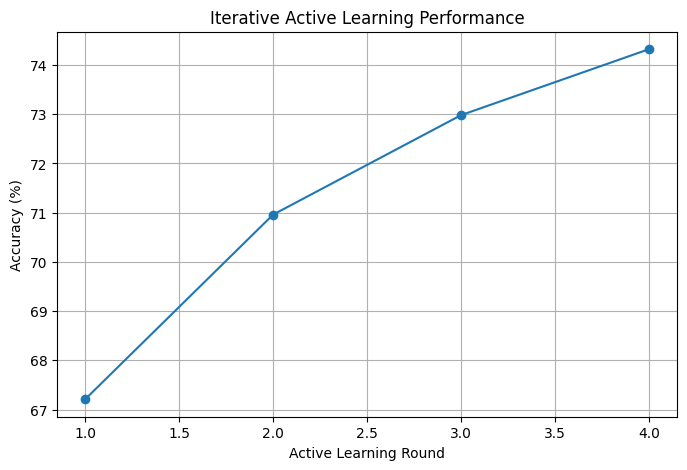

In [16]:
# Visualizing Result
rounds = np.arange(
    1,
    len(results)+1
)

plt.figure(figsize=(8,5))
plt.plot(
    rounds,
    results,
    marker='o'
)

plt.xlabel("Active Learning Round")
plt.ylabel("Accuracy (%)")
plt.title(
    "Iterative Active Learning Performance"
)

plt.grid(True)
plt.show()

In [17]:
# Final Result
print("="*50)
print("FINAL RESULTS")
print("="*50)
for i, acc in enumerate(results):

    print(
        f"Round {i+1}: "
        f"{acc:.2f}%"
    )

FINAL RESULTS
Round 1: 67.21%
Round 2: 70.96%
Round 3: 72.98%
Round 4: 74.32%
